In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import logit

In [3]:
df = pd.read_csv('D600 Task 2 Dataset 1 Housing Information.csv')
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [5]:
selected_columns = [
    'IsLuxury', 'Price', 'SquareFootage', 'NumBathrooms', 'NumBedrooms',
    'BackyardSpace', 'CrimeRate', 'SchoolRating', 'AgeOfHome',
    'DistanceToCityCenter', 'RenovationQuality', 'TransportAccess']
df_selected = df[selected_columns]

In [7]:
descriptive_stats = df_selected.describe(include='all')
modes = df_selected.mode().iloc[0].rename("mode")
descriptive_stats = pd.concat([descriptive_stats, pd.DataFrame(modes).T])
print(descriptive_stats)

         IsLuxury         Price  SquareFootage  NumBathrooms  NumBedrooms  \
count  7000.00000  7.000000e+03    7000.000000   7000.000000  7000.000000   
mean      0.50400  3.072820e+05    1048.947459      2.131397     3.008571   
std       0.50002  1.501734e+05     426.010482      0.952561     1.021940   
min       0.00000  8.500000e+04     550.000000      1.000000     1.000000   
25%       0.00000  1.921075e+05     660.815000      1.290539     2.000000   
50%       1.00000  2.793230e+05     996.320000      1.997774     3.000000   
75%       1.00000  3.918781e+05    1342.292500      2.763997     4.000000   
max       1.00000  1.046676e+06    2874.700000      5.807239     7.000000   
mode      1.00000  8.500000e+04     550.000000      1.000000     3.000000   

       BackyardSpace    CrimeRate  SchoolRating    AgeOfHome  \
count    7000.000000  7000.000000   7000.000000  7000.000000   
mean      511.507029    31.226194      6.942923    46.797046   
std       279.926549    18.025327    

In [9]:
df['IsLuxury'].value_counts()

IsLuxury
1    3528
0    3472
Name: count, dtype: int64

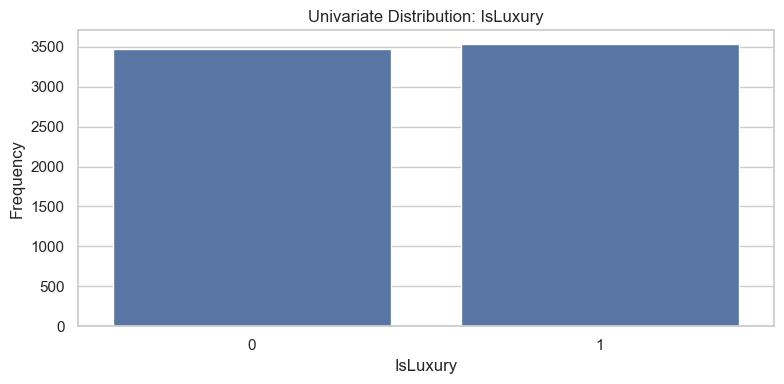

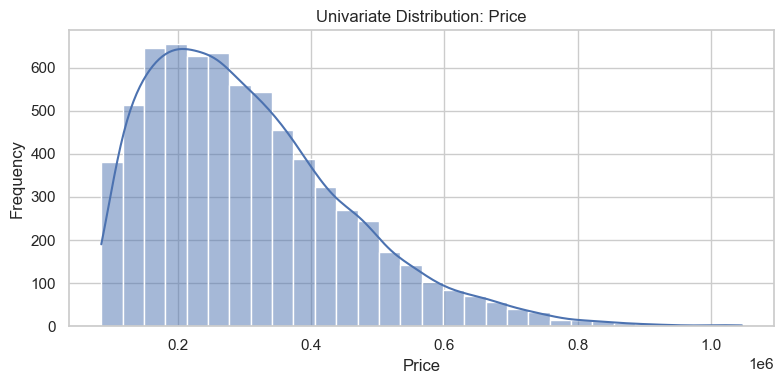

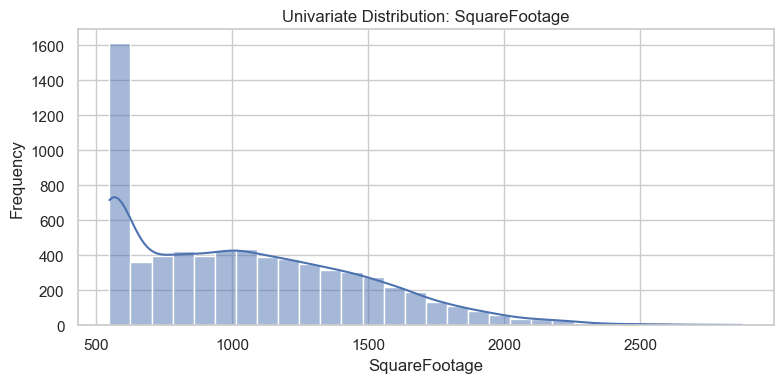

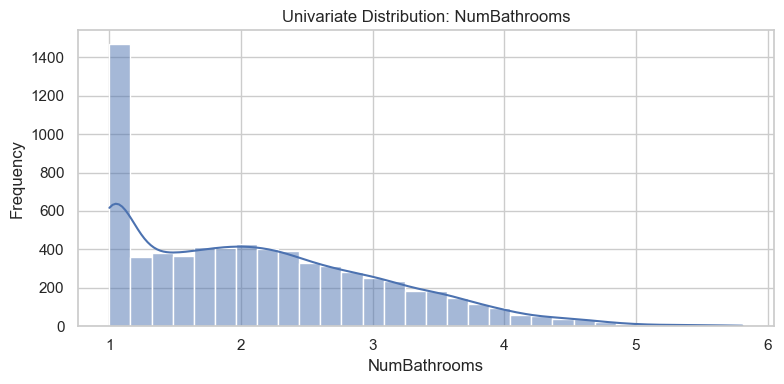

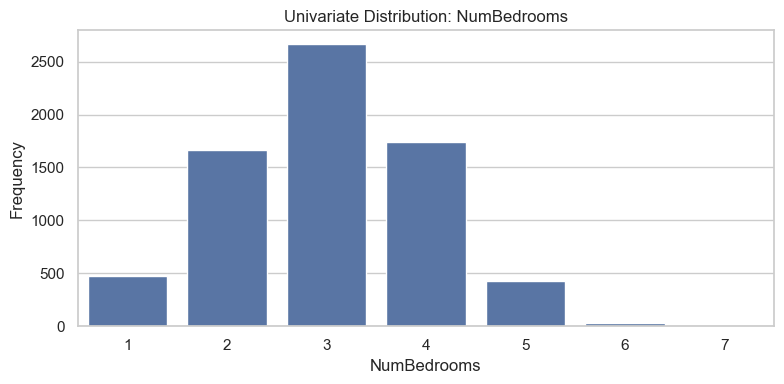

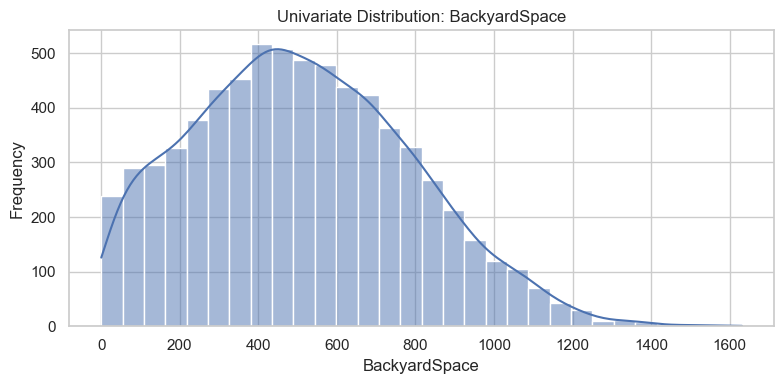

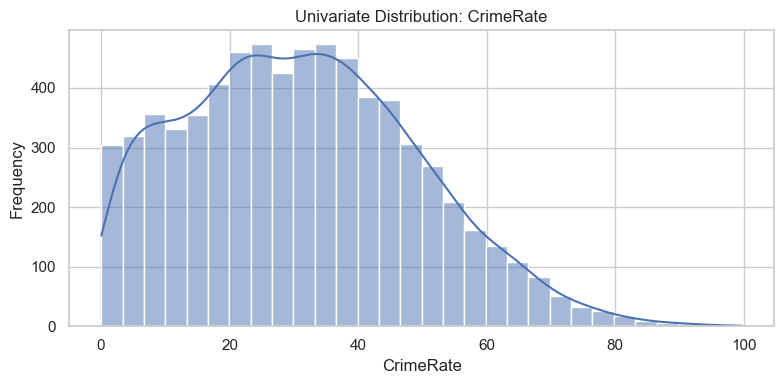

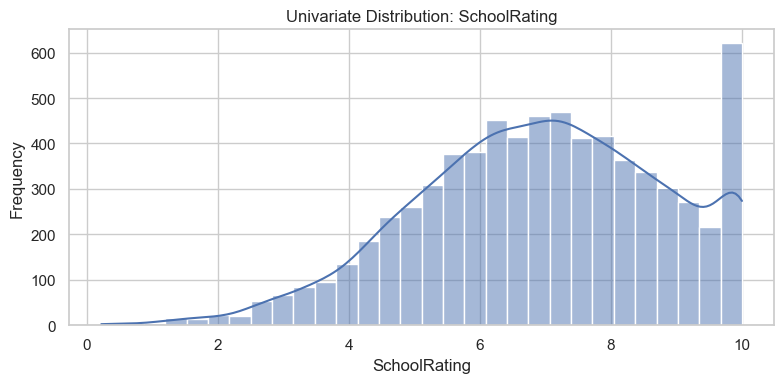

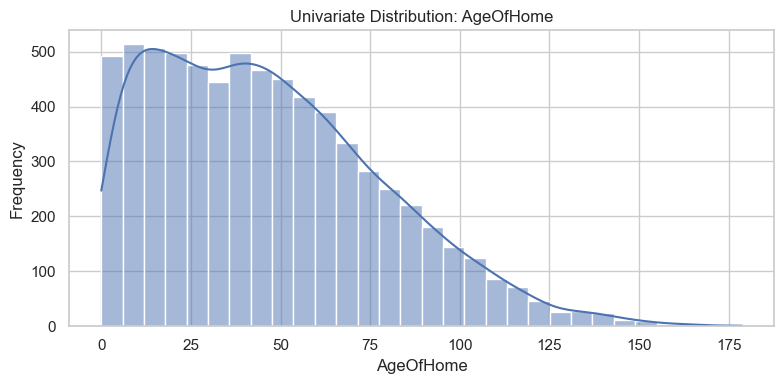

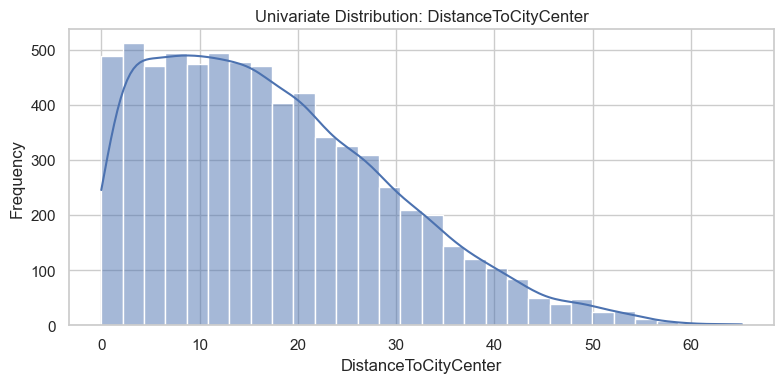

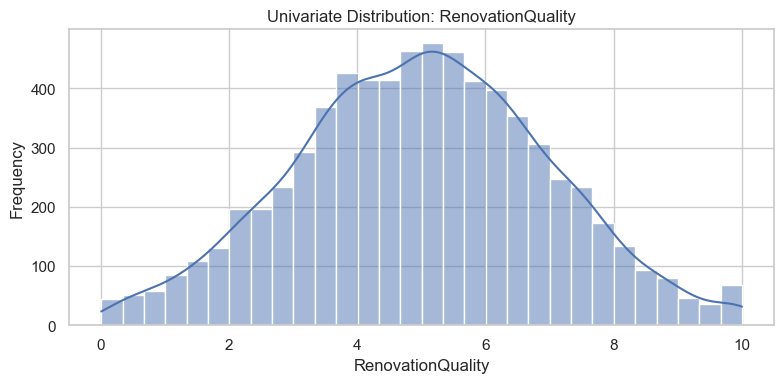

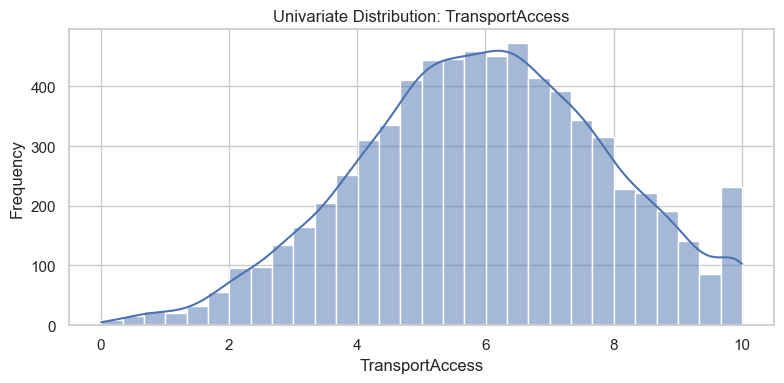

In [11]:
sns.set(style="whitegrid")
for col in selected_columns:
    plt.figure(figsize=(8, 4))
    if df[col].nunique() > 10:
        sns.histplot(df[col], kde=True, bins=30)
    else:
        sns.countplot(x=col, data=df)
    plt.title(f'Univariate Distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

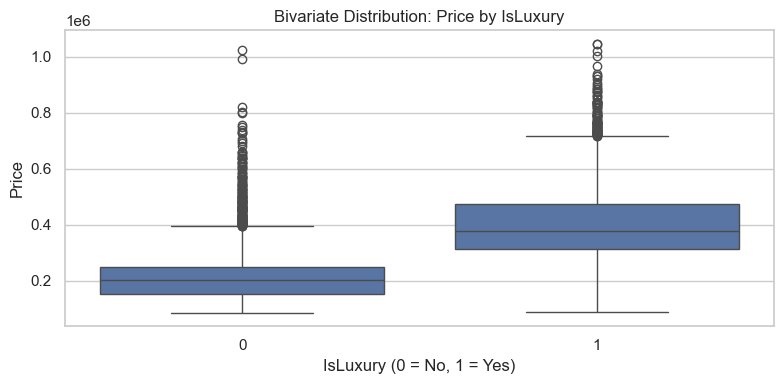

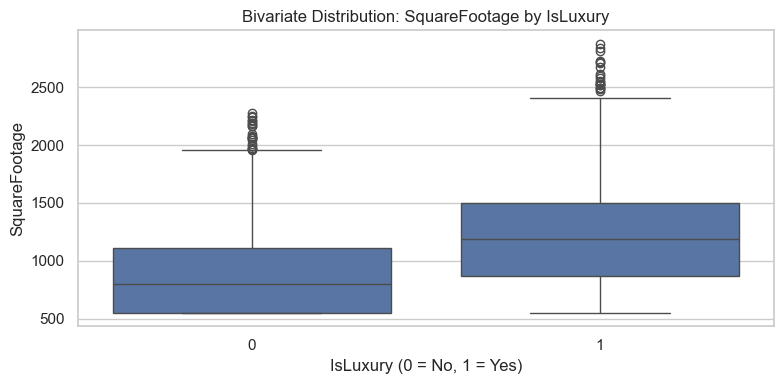

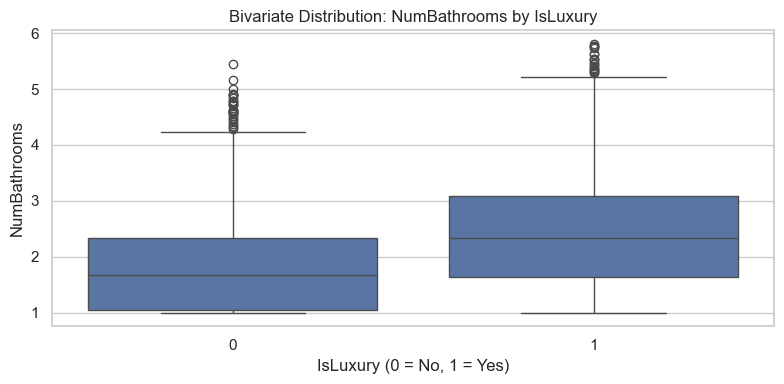

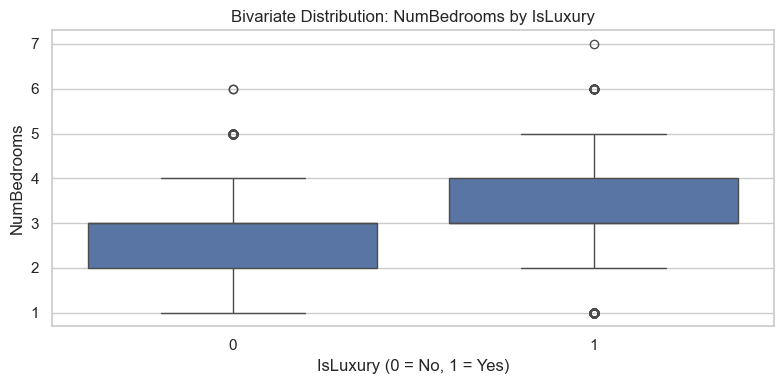

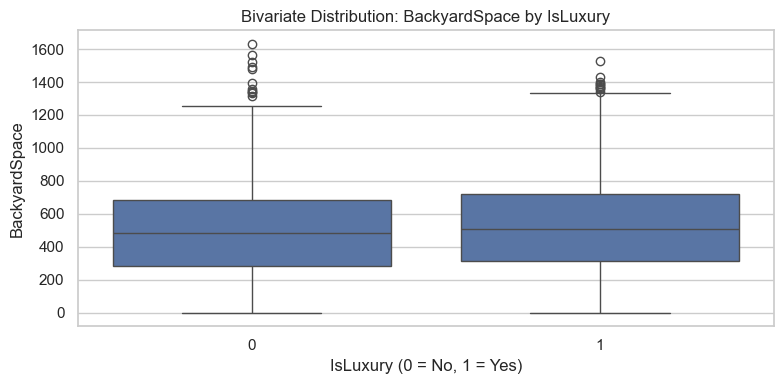

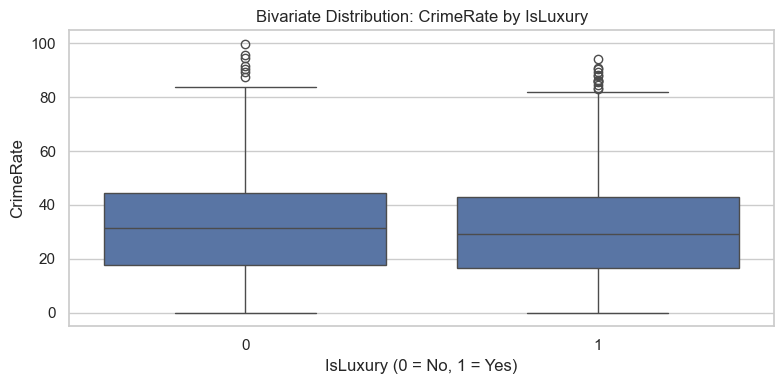

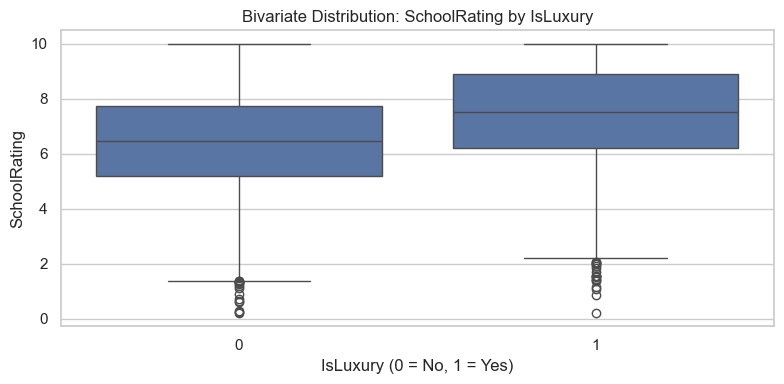

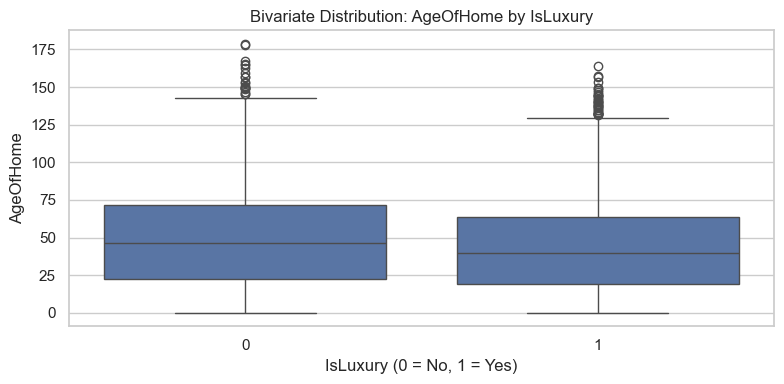

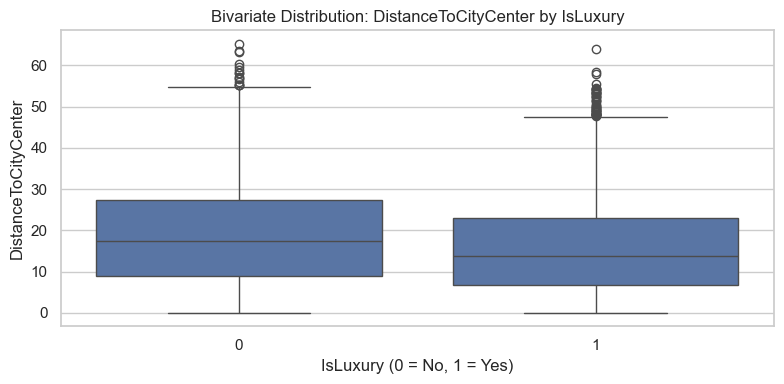

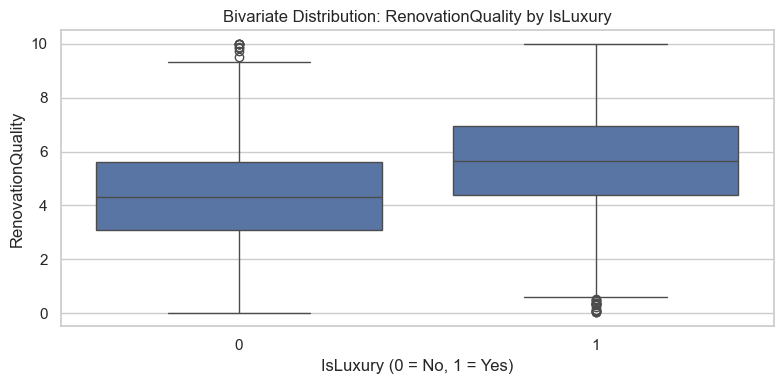

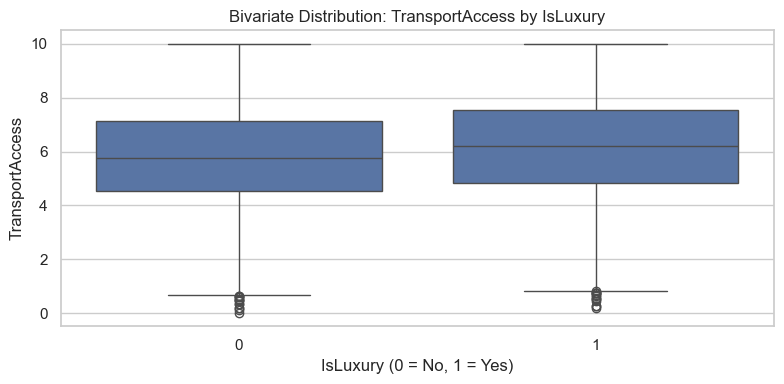

In [13]:
for col in selected_columns:
    if col != 'IsLuxury':
        plt.figure(figsize=(8, 4))
        sns.boxplot(x='IsLuxury', y=col, data=df)
        plt.title(f'Bivariate Distribution: {col} by IsLuxury')
        plt.xlabel('IsLuxury (0 = No, 1 = Yes)')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

In [15]:
X = df[[
    'Price', 'SquareFootage', 'NumBathrooms', 'NumBedrooms', 'BackyardSpace',
    'CrimeRate', 'SchoolRating', 'AgeOfHome', 'DistanceToCityCenter',
    'RenovationQuality', 'TransportAccess']]
y = df['IsLuxury']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
train_const = sm.add_constant(X_train)
X_train.assign(IsLuxury=y_train).to_csv('training_set.csv', index=False)

In [17]:
X_test.assign(IsLuxury=y_test).to_csv('test_set.csv', index=False)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_const = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:               IsLuxury   No. Observations:                 5600
Model:                          Logit   Df Residuals:                     5588
Method:                           MLE   Df Model:                           11
Date:                Fri, 08 Aug 2025   Pseudo R-squ.:                  0.3917
Time:                        13:45:49   Log-Likelihood:                -2360.9
converged:                       True   LL-Null:                       -3881.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3047      0.039      7.868      0.000       0.229       0.381
x1             2.3180      0.079     29.258      0.000       2.163       2.473
x2             0.0886      0.046      1.917      0.0

In [21]:
def backward_stepwise_selection(X, y, threshold_out=0.05):
    remaining_vars = list(X.columns)
    while len(remaining_vars) > 0:
        X_with_const = sm.add_constant(X[remaining_vars])
        model = sm.Logit(y, X_with_const).fit(disp=False)
        p_values = model.pvalues.iloc[1:]  # exclude intercept
        worst_pval = p_values.max()
        if worst_pval > threshold_out:
            worst_feature = p_values.idxmax()
            remaining_vars.remove(worst_feature)
        else:
            break
    final_model = sm.Logit(y, sm.add_constant(X[remaining_vars])).fit(disp=False)
    return final_model, remaining_vars
optimized_model, final_variables = backward_stepwise_selection(X_train, y_train)
model_summary = {
    "Final Variables": final_variables,
    "AIC": optimized_model.aic,
    "BIC": optimized_model.bic,
    "Pseudo R2 (McFadden)": 1 - (optimized_model.llf / optimized_model.llnull),
    "Coefficients": optimized_model.params,
    "P-Values": optimized_model.pvalues}
summary_df = pd.DataFrame({
    "Coefficient": model_summary["Coefficients"],
    "P-Value": model_summary["P-Values"]
})
summary_df["AIC"] = model_summary["AIC"]
summary_df["BIC"] = model_summary["BIC"]
summary_df["Pseudo R2 (McFadden)"] = model_summary["Pseudo R2 (McFadden)"]
import ace_tools_open as tools
tools.display_dataframe_to_user(name="Optimized Logistic Regression Model Summary", dataframe=summary_df)
print("Final variables in the optimized model:", final_variables)

Optimized Logistic Regression Model Summary


Loading ITables v2.4.4 from the internet... (need help?)


Final variables in the optimized model: ['Price', 'NumBedrooms']


In [23]:
X_train_eval_custom = sm.add_constant(X_train[['Price', 'NumBedrooms']])
custom_model = sm.Logit(y_train, X_train_eval_custom).fit(disp=False)
train_probs_custom = custom_model.predict(X_train_eval_custom)
train_preds_custom = (train_probs_custom >= 0.5).astype(int)
train_cm_custom = confusion_matrix(y_train, train_preds_custom)
train_accuracy_custom = accuracy_score(y_train, train_preds_custom)
train_results_custom_df = pd.DataFrame({
    "Set": ["Training"],
    "Accuracy": [train_accuracy_custom],
    "ConfusionMatrix": [train_cm_custom.tolist()]})
tools.display_dataframe_to_user(
    name="Training Set - Confusion Matrix and Accuracy (Price + NumBedrooms)",
    dataframe=train_results_custom_df)

Training Set - Confusion Matrix and Accuracy (Price + NumBedrooms)


Loading ITables v2.4.4 from the internet... (need help?)


In [25]:
X_test_eval_custom = sm.add_constant(X_test[['Price', 'NumBedrooms']])
test_probs_custom = custom_model.predict(X_test_eval_custom)
test_preds_custom = (test_probs_custom >= 0.5).astype(int)
test_cm_custom = confusion_matrix(y_test, test_preds_custom)
test_accuracy_custom = accuracy_score(y_test, test_preds_custom)
test_results_custom_df = pd.DataFrame({
    "Set": ["Test"],
    "Accuracy": [test_accuracy_custom],
    "ConfusionMatrix": [test_cm_custom.tolist()]})
tools.display_dataframe_to_user(
    name="Test Set - Confusion Matrix and Accuracy (Price + NumBedrooms)",
    dataframe=test_results_custom_df)

Test Set - Confusion Matrix and Accuracy (Price + NumBedrooms)


Loading ITables v2.4.4 from the internet... (need help?)


In [27]:
print("Unique values in IsLuxury:", df['IsLuxury'].unique())

Unique values in IsLuxury: [0 1]


/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


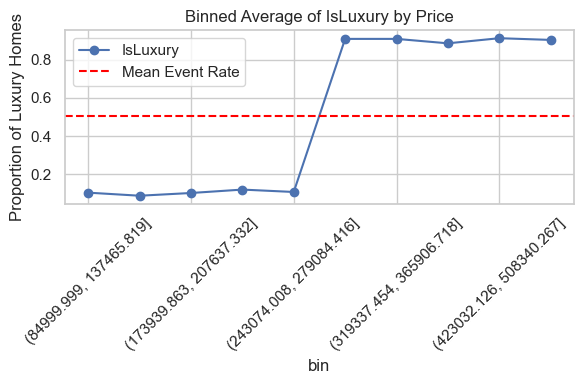

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


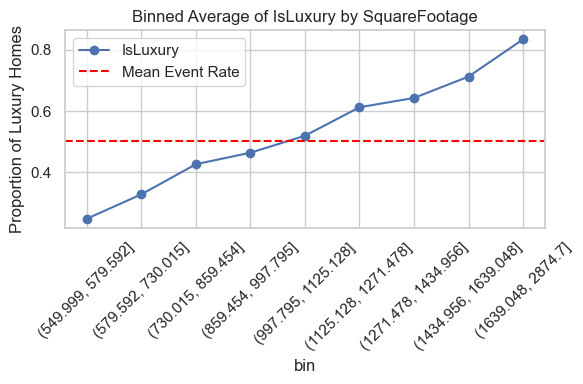

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


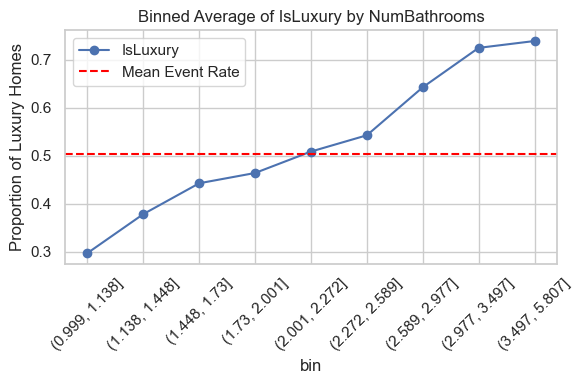

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


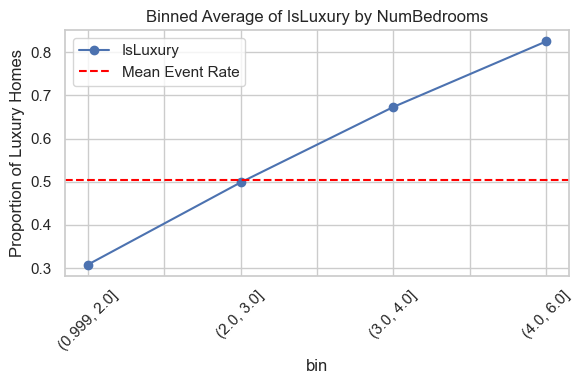

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


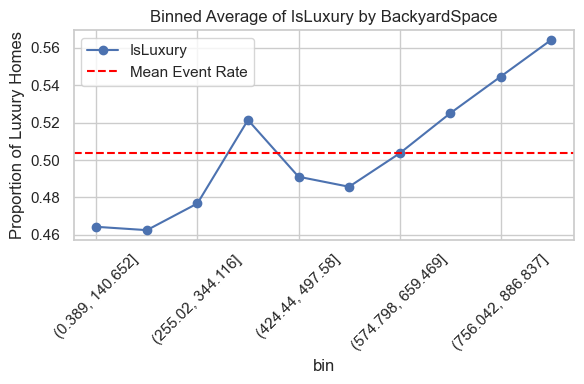

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


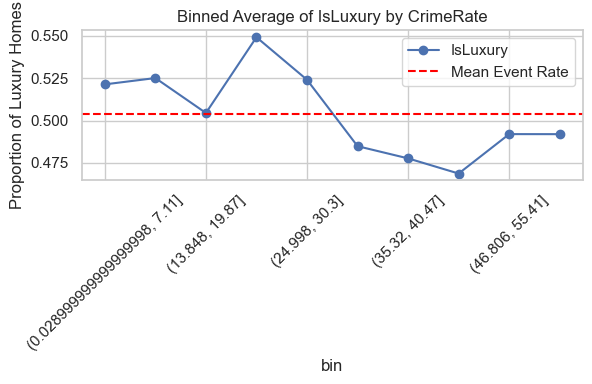

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


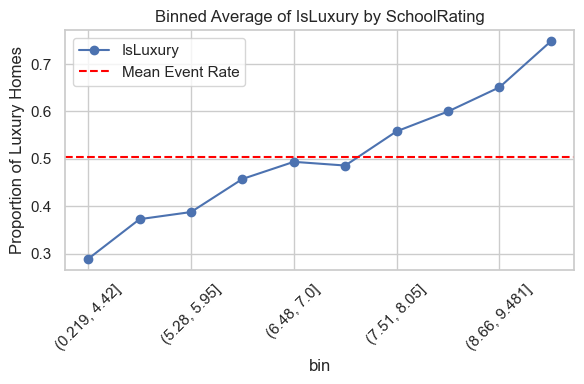

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


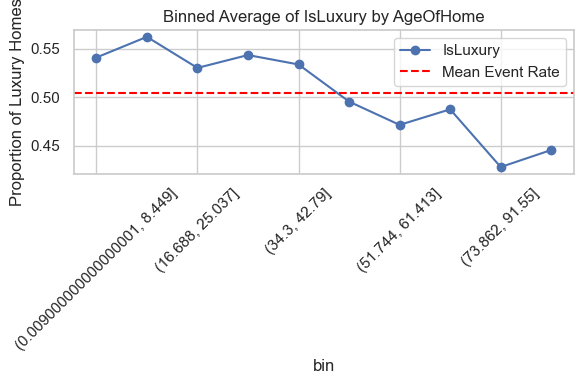

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


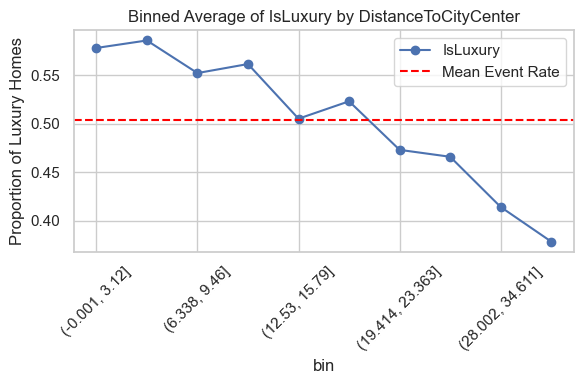

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


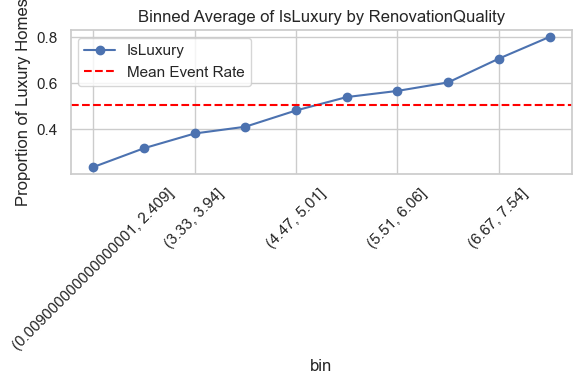

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/121912401.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_plot.groupby('bin')['IsLuxury'].mean()


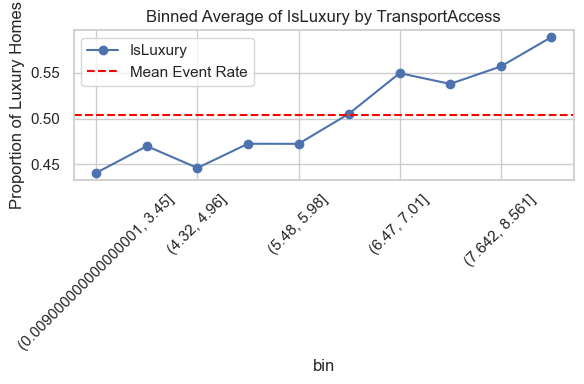

In [29]:
features = [
    'Price', 'SquareFootage', 'NumBathrooms', 'NumBedrooms', 'BackyardSpace',
    'CrimeRate', 'SchoolRating', 'AgeOfHome', 'DistanceToCityCenter',
    'RenovationQuality', 'TransportAccess'
]
target = 'IsLuxury'

y_mean = y_train.mean() 

for i, col in enumerate(features):
    df_plot = pd.DataFrame({
        col: X_train[col],
        'IsLuxury': y_train
    })

    df_plot['bin'] = pd.qcut(df_plot[col], q=10, duplicates='drop')
    grouped = df_plot.groupby('bin')['IsLuxury'].mean()

    plt.figure(figsize=(6, 4))
    grouped.plot(marker='o')
    plt.axhline(y=y_mean, color='red', linestyle='--', label='Mean Event Rate')
    plt.title(f'Binned Average of IsLuxury by {col}')
    plt.ylabel('Proportion of Luxury Homes')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_train_const = sm.add_constant(X_train_scaled)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

coef_table = pd.DataFrame({
    'Variable': ['Intercept'] + features,
    'Coefficient (β)': result.params.round(4),
    'P-Value': result.pvalues.round(4)
})

print("Logistic Regression Equation:")
equation = f"log(P / (1 - P)) = {result.params[0]:.4f}"
for i, feature in enumerate(features, start=1):
    sign = "+" if result.params[i] >= 0 else "-"
    equation += f" {sign} {abs(result.params[i]):.4f} * {feature}"
print(equation)

# Show coefficients table
print("\nCoefficient Table:")
print(coef_table)

Logistic Regression Equation:
log(P / (1 - P)) = 0.3047 + 2.3180 * Price + 0.0886 * SquareFootage + 0.0403 * NumBathrooms + 0.1146 * NumBedrooms + 0.0342 * BackyardSpace + 0.0439 * CrimeRate - 0.0440 * SchoolRating + 0.0453 * AgeOfHome + 0.0361 * DistanceToCityCenter + 0.0339 * RenovationQuality + 0.0040 * TransportAccess

Coefficient Table:
                   Variable  Coefficient (β)  P-Value
const             Intercept           0.3047   0.0000
x1                    Price           2.3180   0.0000
x2            SquareFootage           0.0886   0.0552
x3             NumBathrooms           0.0403   0.3462
x4              NumBedrooms           0.1146   0.0099
x5            BackyardSpace           0.0342   0.3477
x6                CrimeRate           0.0439   0.2333
x7             SchoolRating          -0.0440   0.3269
x8                AgeOfHome           0.0453   0.2215
x9     DistanceToCityCenter           0.0361   0.3327
x10       RenovationQuality           0.0339   0.4603
x11     

/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/3313935851.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  equation = f"log(P / (1 - P)) = {result.params[0]:.4f}"
/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/3313935851.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sign = "+" if result.params[i] >= 0 else "-"
/var/folders/x2/ytwl41l10m5g6_54xpjtyr5w0000gn/T/ipykernel_27322/3313935851.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). T

In [33]:
print(df['IsLuxury'].value_counts())

IsLuxury
1    3528
0    3472
Name: count, dtype: int64


In [35]:
df['Price_log'] = df['Price'] * np.log(df['Price'])
df['NumBedrooms_log'] = df['NumBedrooms'] * np.log(df['NumBedrooms'])
box_tidwell_model = logit('IsLuxury ~ Price + NumBedrooms + Price_log + NumBedrooms_log', data=df).fit()
print(box_tidwell_model.summary())

Optimization terminated successfully.
         Current function value: 0.407199
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               IsLuxury   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6995
Method:                           MLE   Df Model:                            4
Date:                Fri, 08 Aug 2025   Pseudo R-squ.:                  0.4125
Time:                        13:47:33   Log-Likelihood:                -2850.4
converged:                       True   LL-Null:                       -4851.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -10.7315      0.545    -19.678      0.000     -11.800      -9.663
Price         

In [37]:
print(df.duplicated().sum())

0


In [39]:
X_vif = sm.add_constant(X_train[['Price', 'NumBedrooms']])
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

      Variable        VIF
0        const  10.385947
1        Price   1.258146
2  NumBedrooms   1.258146
